# Tópicos em Otimização Irrestrita

### Pacotes importados

In [23]:
using LinearAlgebra
using Printf

### Machine epsilon

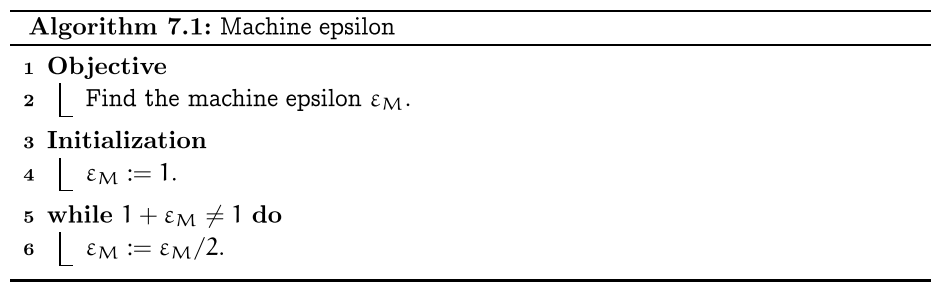

In [24]:
# Algoritmo 7.1: Machine epsilon
function encontrar_machine_epsilon()
    eps_m = 1.0
    while (1.0 + eps_m != 1.0)
        eps_m = eps_m / 2.0
    end
    # O valor real é o dobro do último que falhou no teste
    return eps_m * 2.0
end

m_eps = encontrar_machine_epsilon()
println("Machine Epsilon calculado: ", m_eps)
println("Valor nativo do Julia:    ", eps(Float64))

Machine Epsilon calculado: 2.220446049250313e-16
Valor nativo do Julia:    2.220446049250313e-16


### Newton's method: one variable

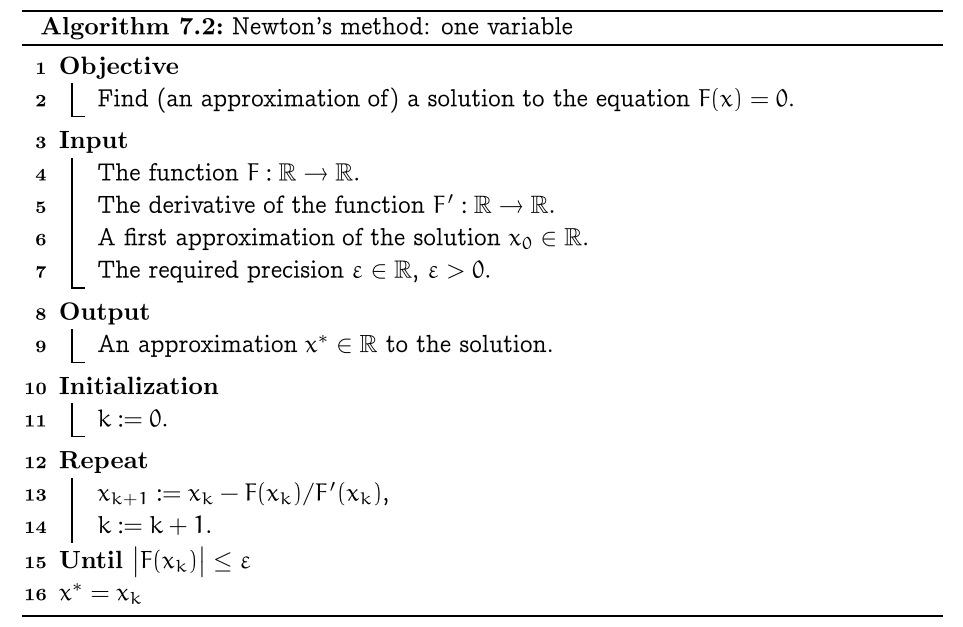

Take the equation: $F(x) = x^2 - 2 = 0$. Apply the Newton's method with $x_0 = 2, \epsilon = 10^{-15}$. Present the results such as the following:

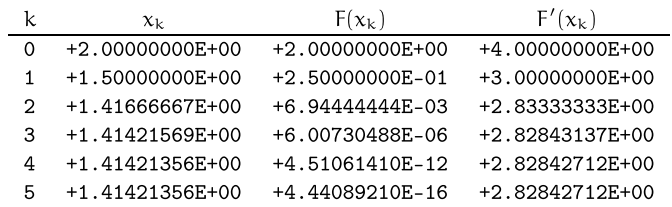

Also plot the graph with the iterations $\times$ the value of F(x).

In [25]:
# Definição das funções
F(x) = x^2 - 2
dF(x) = 2x

function metodo_newton_univariado(x0, epsilon)
    xk = Float64(x0)
    k = 0
    
    println("k   | xk                   | F(xk)")
    println("-"^40)
    
    # Repetir até que |F(xk)| <= epsilon
    while abs(F(xk)) > epsilon
        @printf("%-3d | %-20.15f | %-20.15e\n", k, xk, F(xk))
        
        xk = xk - F(xk) / dF(xk)
        k += 1
        
        if k > 100 break end
    end
    
    @printf("%-3d | %-20.15f | %-20.15e\n", k, xk, F(xk))
    return xk
end

# Se o VS Code reclamar do @printf, adicione: using Printf
using Printf 

resultado = metodo_newton_univariado(2.0, 1e-15)
println("\nResultado final: ", resultado)

k   | xk                   | F(xk)
----------------------------------------
0   | 2.000000000000000    | 2.000000000000000e+00
1   | 1.500000000000000    | 2.500000000000000e-01
2   | 1.416666666666667    | 6.944444444444642e-03
3   | 1.414215686274510    | 6.007304882871267e-06
4   | 1.414213562374690    | 4.510614104447086e-12
5   | 1.414213562373095    | 4.440892098500626e-16

Resultado final: 1.4142135623730951


Another example: $F(x)=x-\sin(x)$. Run the example with $x_0=1$ and $\varepsilon=10^{-15}$.

In [26]:
# Definição da nova função e sua derivada
F_novo(x) = x - sin(x)
dF_novo(x) = 1 - cos(x)

# Parâmetros
x0 = 1.0
epsilon = 1e-15

function exercicio_newton_lento(x0, eps)
    xk = Float64(x0)
    k = 0
    
    println("k   | xk                   | F(xk)")
    println("-"^45)
    
    # O loop continua enquanto o valor absoluto de F(xk) for maior que epsilon
    while abs(F_novo(xk)) > eps
        # Mostra as iterações (limitei o print para não travar o VS Code se demorar muito)
        if k % 10 == 0 || k < 5
            @printf("%-3d | %-20.15f | %-20.15e\n", k, xk, F_novo(xk))
        end
        
        # Passo de Newton
        xk = xk - F_novo(xk) / dF_novo(xk)
        k += 1
        
        # Segurança para não ficar em loop infinito caso a precisão 1e-15 não seja atingida
        if k > 1000 break end
    end
    
    println("-"^45)
    @printf("Final | %-20.15f | %-20.15e\n", xk, F_novo(xk))
    println("Total de iterações: ", k)
    return xk
end

resultado_lento = exercicio_newton_lento(x0, epsilon)

k   | xk                   | F(xk)
---------------------------------------------
0   | 1.000000000000000    | 1.585290151921035e-01
1   | 0.655145072042430    | 4.587078604089578e-02
2   | 0.433590368363493    | 1.345873795940100e-02
3   | 0.288148400892501    | 3.970948460417290e-03
4   | 0.191832312150639    | 1.174396923293297e-03
10  | 0.016822797810871    | 7.934823667461732e-07
20  | 0.000291730575180    | 4.138039140944710e-12
---------------------------------------------
Final | 0.000017074312016    | 8.296179498587519e-16
Total de iterações: 27


1.7074312016207497e-5

Another example: $F(x)=\arctan(x)$. Run the example with $x_0=1.5$ and $\varepsilon=10^{-15}$. We set `maxiter` to 10, as the algorithm is not converging.

In [27]:
# Definição da função e sua derivada
F_arctan(x) = atan(x)
dF_arctan(x) = 1 / (1 + x^2)

# Parâmetros solicitados
x0 = 1.5
epsilon = 1e-15
maxiter = 10

function exercicio_newton_divergente(x0, eps, max_it)
    xk = Float64(x0)
    
    println("k   | xk                   | F(xk)")
    println("-"^45)
    
    for k in 0:max_it
        val_f = F_arctan(xk)
        @printf("%-3d | %-20.15f | %-20.15e\n", k, xk, val_f)
        
        # Critério de parada
        if abs(val_f) <= eps
            println("\nConvergiu!")
            return xk
        end
        
        # Passo de Newton
        xk = xk - val_f / dF_arctan(xk)
    end
    
    println("-"^45)
    println("Atenção: Algoritmo atingiu o limite de $max_it iterações sem convergir.")
    return xk
end

resultado_divergente = exercicio_newton_divergente(x0, epsilon, maxiter)# codigo aqui

k   | xk                   | F(xk)
---------------------------------------------
0   | 1.500000000000000    | 9.827937232473291e-01
1   | -1.694079600553819   | -1.037546359137891e+00
2   | 2.321126961438388    | 1.164002042421975e+00
3   | -5.114087836777514   | -1.377694528702752e+00
4   | 32.295683914210016   | 1.539842326908012e+00
5   | -1575.316950821204273 | -1.570161533990085e+00
6   | 3894976.007760884240270 | 1.570796070053906e+00
7   | -23830288973552.125000000000000 | -1.570796326794855e+00
8   | 892028016112381788726231040.000000000000000 | 1.570796326794897e+00
9   | -1249904599365710657638556704759460448487685400492507136.000000000000000 | -1.570796326794897e+00
10  | 2453994637498495522179279697526916057699567372002681230504971233646742496400468656445422854640968559407136768.000000000000000 | 1.570796326794897e+00
---------------------------------------------
Atenção: Algoritmo atingiu o limite de 10 iterações sem convergir.


-9.459476350342202e216

### Algorithm 7.3: Newton's method: $n$ variables

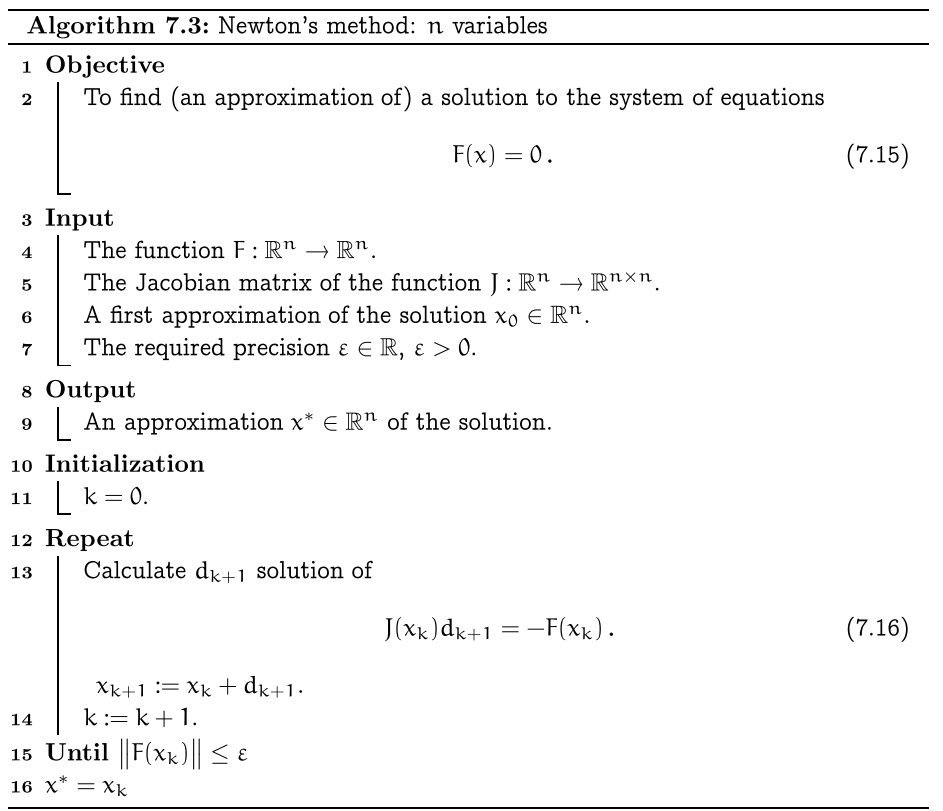

Example: $F(x)=\left(\begin{array}{c}(x_1+1)^2+ x_2^2 - 2 \\ e^{x_1} + x_2^3 - 2 \end{array}\right)$. Run the example with $x_0= \left(\begin{array}{c} 1 \\ 1 \end{array}\right)$ and $\varepsilon = 10^{-15}$

In [28]:
# 1. Definição da função F(x) que retorna um vetor
function F_sys(x)
    return [
        (x[1] + 1)^2 + x[2]^2 - 2,
        exp(x[1]) + x[2]^3 - 2
    ]
end

# 2. Definição da Matriz Jacobiana J(x)
function J_sys(x)
    return [
        2*(x[1] + 1)    2*x[2];       # Derivadas da primeira linha
        exp(x[1])       3*x[2]^2      # Derivadas da segunda linha
    ]
end

# 3. Função do Algoritmo 7.3
function metodo_newton_n_variaveis(x0, eps)
    xk = Float64.(x0)
    k = 0
    
    println("k   | xk' (transposto)          | ||F(xk)||")
    println("-"^50)
    
    # O critério de parada usa a norma do vetor F(xk)
    while norm(F_sys(xk)) > eps
        fk = F_sys(xk)
        jk = J_sys(xk)
        
        @printf("%-3d | [%.8f, %.8f] | %.8e\n", k, xk[1], xk[2], norm(fk))
        
        # Calcular dk+1 resolvendo o sistema: J(xk) * d = -F(xk)
        # No Julia, H \ -g é o jeito mais estável e rápido
        dk = jk \ -fk
        
        # Atualizar xk e o contador
        xk = xk + dk
        k += 1
        
        if k > 100 break end # Proteção
    end
    
    println("-"^50)
    @printf("Final | [%.15f, %.15f]\n", xk[1], xk[2])
    println("Iterações: ", k)
    return xk
end

# Execução do exemplo solicitado
x0 = [1.0, 1.0]
epsilon = 1e-15
resultado_final = metodo_newton_n_variaveis(x0, epsilon)

k   | xk' (transposto)          | ||F(xk)||
--------------------------------------------------
0   | [1.00000000, 1.00000000] | 3.45723769e+00
1   | [0.15235921, 1.19528157] | 1.15470871e+00
2   | [-0.01083768, 1.03611117] | 1.14042558e-01
3   | [-0.00088966, 1.00153532] | 3.94232976e-03
4   | [-0.00000137, 1.00000294] | 8.07998556e-06
5   | [-0.00000000, 1.00000000] | 2.88311226e-11
--------------------------------------------------
Final | [-0.000000000000000, 1.000000000000000]
Iterações: 6


2-element Vector{Float64}:
 -1.0463793574265223e-16
  1.0000000000000002

Example: $F(x)=\left(\begin{array}{c}x_1^3 - 3 x_1 x_2^2 -1 \\ x_2^3 - 3x_1^2 x_2\end{array}\right)$. Run the example with $x_0= \left(\begin{array}{c} 1 \\ 1 \end{array}\right)$ and $\varepsilon = 10^{-15}$

In [29]:
# 1. Definição do Sistema de Equações F(x)
function F_sistema_2(x)
    return [
        x[1]^3 - 3*x[1]*x[2]^2 - 1,
        x[2]^3 - 3*x[1]^2*x[2]
    ]
end

# 2. Definição da Matriz Jacobiana J(x)
function J_sistema_2(x)
    return [
        (3*x[1]^2 - 3*x[2]^2)   (-6*x[1]*x[2]);
        (-6*x[1]*x[2])          (3*x[2]^2 - 3*x[1]^2)
    ]
end

# 3. Execução do Algoritmo 7.3 para este sistema
function resolver_exercicio_final(x0, eps)
    xk = Float64.(x0)
    k = 0
    
    println("Iteração k | x1                 | x2                 | ||F(xk)||")
    println("-"^75)
    
    while norm(F_sistema_2(xk)) > eps
        fk = F_sistema_2(xk)
        jk = J_sistema_2(xk)
        
        @printf("%-10d | %-18.15f | %-18.15f | %.2e\n", k, xk[1], xk[2], norm(fk))
        
        # Resolve o sistema J * d = -F
        dk = jk \ -fk
        
        # Atualização
        xk = xk + dk
        k += 1
        
        if k > 100 
            println("Atingiu limite de iterações.")
            break 
        end
    end
    
    @printf("%-10d | %-18.15f | %-18.15f | %.2e\n", k, xk[1], xk[2], norm(F_sistema_2(xk)))
    println("-"^75)
    return xk
end

# Parâmetros do enunciado
x0 = [1.0, 1.0]
epsilon = 1e-15

resultado = resolver_exercicio_final(x0, epsilon)

Iteração k | x1                 | x2                 | ||F(xk)||
---------------------------------------------------------------------------
0          | 1.000000000000000  | 1.000000000000000  | 3.61e+00
1          | 0.666666666666667  | 0.500000000000000  | 1.32e+00
2          | 0.578844444444444  | -0.127466666666667 | 8.44e-01
3          | 1.246963981575016  | 0.313578425154997  | 1.54e+00
4          | 1.008948197751505  | 0.113677965154901  | 3.46e-01
5          | 0.987868045978376  | 0.003836843642865  | 3.77e-02
6          | 1.000134144210213  | -0.000095322185096 | 4.94e-04
7          | 1.000000008910006  | -0.000000025568133 | 8.12e-08
8          | 0.999999999999999  | -0.000000000000000 | 2.15e-15
9          | 1.000000000000000  | 0.000000000000000  | 1.48e-30
---------------------------------------------------------------------------


2-element Vector{Float64}:
 1.0
 4.930380657631324e-31

Run the example with $x_0= \left(\begin{array}{c} -1 \\ -1 \end{array}\right)$ and $\varepsilon = 10^{-15}$

In [30]:
# O sistema e a Jacobiana permanecem os mesmos da célula anterior
# F1(x) = x1^3 - 3*x1*x2^2 - 1
# F2(x) = x2^3 - 3*x1^2*x2

function F_sistema_final(x)
    return [
        x[1]^3 - 3*x[1]*x[2]^2 - 1,
        x[2]^3 - 3*x[1]^2*x[2]
    ]
end

function J_sistema_final(x)
    return [
        (3*x[1]^2 - 3*x[2]^2)   (-6*x[1]*x[2]);
        (-6*x[1]*x[2])          (3*x[2]^2 - 3*x[1]^2)
    ]
end

# Execução com o novo ponto inicial x0 = [-1, -1]
function executar_com_novo_x0(x0_input, eps)
    xk = Float64.(x0_input)
    k = 0
    
    println("Iteração k | x1                 | x2                 | ||F(xk)||")
    println("-"^75)
    
    while norm(F_sistema_final(xk)) > eps
        fk = F_sistema_final(xk)
        jk = J_sistema_final(xk)
        
        @printf("%-10d | %-18.15f | %-18.15f | %.2e\n", k, xk[1], xk[2], norm(fk))
        
        # Passo de Newton: dk = J \ -F
        dk = jk \ -fk
        xk = xk + dk
        k += 1
        
        if k > 100 break end
    end
    
    @printf("%-10d | %-18.15f | %-18.15f | %.2e\n", k, xk[1], xk[2], norm(F_sistema_final(xk)))
    println("-"^75)
    return xk
end

# Parâmetros solicitados pela imagem
x0_novo = [-1.0, -1.0]
epsilon = 1e-15

resultado_2 = executar_com_novo_x0(x0_novo, epsilon)

Iteração k | x1                 | x2                 | ||F(xk)||
---------------------------------------------------------------------------
0          | -1.000000000000000 | -1.000000000000000 | 2.24e+00
1          | -0.666666666666667 | -0.833333333333333 | 5.40e-01
2          | -0.508691916187455 | -0.841099874413378 | 7.78e-02
3          | -0.499329995643751 | -0.866269171788006 | 2.14e-03
4          | -0.499999911369913 | -0.866024903156889 | 1.53e-06
5          | -0.499999999999955 | -0.866025403784693 | 7.75e-13
6          | -0.500000000000000 | -0.866025403784439 | 2.48e-16
---------------------------------------------------------------------------


2-element Vector{Float64}:
 -0.49999999999999994
 -0.8660254037844386

Run the example with $x_0= \left(\begin{array}{c} 0 \\ 1 \end{array}\right)$ and $\varepsilon = 10^{-15}$

In [31]:
# Reutilizando as funções F e J já definidas anteriormente
# Se necessário, você pode redefini-las aqui para garantir que a célula seja independente:

function F_sistema_final(x)
    return [
        x[1]^3 - 3*x[1]*x[2]^2 - 1,
        x[2]^3 - 3*x[1]^2*x[2]
    ]
end

function J_sistema_final(x)
    return [
        (3*x[1]^2 - 3*x[2]^2)   (-6*x[1]*x[2]);
        (-6*x[1]*x[2])          (3*x[2]^2 - 3*x[1]^2)
    ]
end

# Execução com o ponto inicial x0 = [0, 1]
function executar_desafio_final(x0_input, eps)
    xk = Float64.(x0_input)
    k = 0
    
    println("Iteração k | x1                 | x2                 | ||F(xk)||")
    println("-"^75)
    
    # Loop de Newton (Algoritmo 7.3)
    while norm(F_sistema_final(xk)) > eps
        fk = F_sistema_final(xk)
        jk = J_sistema_final(xk)
        
        @printf("%-10d | %-18.15f | %-18.15f | %.2e\n", k, xk[1], xk[2], norm(fk))
        
        # d = J \ -F
        dk = jk \ -fk
        xk = xk + dk
        k += 1
        
        if k > 50 break end # Newton converge rápido; se passar de 50, algo está errado
    end
    
    @printf("%-10d | %-18.15f | %-18.15f | %.2e\n", k, xk[1], xk[2], norm(F_sistema_final(xk)))
    println("-"^75)
    return xk
end

# Parâmetros da oitava imagem
x0_8 = [0.0, 1.0]
epsilon = 1e-15

resultado_8 = executar_desafio_final(x0_8, epsilon)

Iteração k | x1                 | x2                 | ||F(xk)||
---------------------------------------------------------------------------
0          | 0.000000000000000  | 1.000000000000000  | 1.41e+00
1          | -0.333333333333333 | 0.666666666666667  | 5.97e-01
2          | -0.582222222222222 | 0.924444444444444  | 3.31e-01
3          | -0.508790803289319 | 0.868165511887349  | 2.73e-02
4          | -0.500068739067393 | 0.865982218692540  | 2.44e-04
5          | -0.499999996289030 | 0.866025398338587  | 1.98e-08
6          | -0.500000000000000 | 0.866025403784439  | 4.97e-16
---------------------------------------------------------------------------


2-element Vector{Float64}:
 -0.5000000000000001
  0.8660254037844387